In [2]:
import xgi
import numpy as np
import pickle
from random import shuffle
from multiprocess import Pool
from tqdm import tqdm
from had_model import *
import matplotlib.pyplot as plt

In [3]:
# draw N variables from bimodal distribution in [0,1]
def bimodal_distribution(N, means, std):
    n_samp = N*2
    samp1 = np.random.normal(means[0], std, n_samp)
    samp2 = np.random.normal(means[1], std, n_samp)
    samp = [i for i in np.hstack((samp1,samp2)) if i>0. and i<1.]
    shuffle(samp)
    return samp[:N]
    
# auxiliary functions to parallelize computations
def get_results(args):

    N, ks_avg, eps, cond, bimod, means, std = args
    H = stratified_er_hypergraph(N, ks_avg, p_type='degree')
    H.cleanup()
    groups_0 = H.edges.members()
    opinions_0 = bimodal_distribution(N, means, std) if bimod else None
    
    Model = HAD_model(eps, groups_0, opinions_0)
    results = Model.simulate(condition=cond)
    opinions = results['opinions']
    groups = results['groups']
    n_events = results['n_events']

    return (groups, opinions, len(groups_0), n_events)

# 1) Main results at steady state, as a function of $\epsilon$

In [7]:
### SET PARAMETERS OF THE MODEL
Ns = [500, 1000, 2000, 5000]
cond = 'max_min'    # 'max_min' or 'std'
iterations = 20     # number of runs for each epsilon
n_process = 7       # number of processes for parallelization

epsilons = np.linspace(0., 0.6, num=25)[1:]
if cond=='std':
    epsilons = np.linspace(0., 0.4, num=17)[1:]

# hyperedge structure of initial hypergraph (e.g. [3,0,3] means avg degree at sizes s=2,4 is k_s=3)
ks_avg = [3,0,3,0,3]

bimodal = True   # if 'True' set mean and std of the two gaussian
std = 0.1
means_list = [[0.3,0.7], [0.2,0.8], [0.1,0.9]]

for means in means_list:
   
    ncc = dict()
    scc1 = dict()
    scc2 = dict()
    nhe = dict()
    s_avg = dict()
    s_max = dict()
    n_tsteps = dict()
    
    for N in Ns:
        
        # All below quantities are computed at the steady state, as a function of epsilon, averaged over 'iterations'
        ncc[N] = []      # number of connected components
        scc1[N] = []     # size of the largest connected component
        scc2[N] = []     # size of the second largest connected component
        nhe[N] = []      # number of hyperedges
        s_avg[N] = []    # average hyperedge size
        s_max[N] = []    # max hyperedge size
        n_tsteps[N] = [] # number of timesteps (convergence time)
                      
        for eps in tqdm(epsilons):
    
            p = Pool(processes=n_process)
            args = [(N, ks_avg, eps, cond, bimodal, means, std)] * iterations
            res_runs = p.map(get_results, args)
    
            ncc_it = []
            scc1_it = []
            scc2_it = []
            nhe_it = []
            s_avg_it = []
            s_max_it = []
            n_tsteps_it = []
    
            # loop over iterations
            for res in res_runs:     
                
                groups, opinions, ng_0 = res[0], res[1], res[2]
                n_tsteps_it.append(len(groups))
                # number of connected components and size of the two largest
                hedges_fin = groups[-1]
                h = xgi.Hypergraph(hedges_fin)
                # list of connected components
                cc = [j for j in xgi.connected_components(h)]
                ncc_it.append( len(cc) )                    
                scc = set([len(i) for i in cc])
                scc1_it.append( max(scc) / N )
                scc.remove(max(scc))
                if scc:
                    scc2_it.append( max(scc) / N )
                else:
                    scc2_it.append(0)
        
                # relative number of hyperedges
                nhe_it.append( len(groups[-1]) / ng_0 )
                # relative avg and std of hyperedge sizes
                sizes_end_it = [len(e) for e in groups[-1]]
                s_avg_it.append( np.mean(sizes_end_it) )
                s_max_it.append( np.max(sizes_end_it) )
                
            ncc[N].append(np.mean(ncc_it))
            scc1[N].append(np.mean(scc1_it))
            scc2[N].append(np.mean(scc2_it))
            nhe[N].append(np.mean(nhe_it))
            s_avg[N].append(np.mean(s_avg_it))
            s_max[N].append(np.mean(s_max_it))
            n_tsteps[N].append(np.mean(n_tsteps_it))
    
    results = {
        'ncc': ncc,
        'scc1': scc1,
        'scc2': scc2,
        'nhe': nhe,
        's_avg': s_avg,
        's_max': s_max,
        'n_timesteps': n_tsteps,
        'epsilons': epsilons,
        'ks_avg': ks_avg,
        'n_iter': iterations
        }
    
    # save results
    bm_str = f'_bimodal_{means[0]}_{means[1]}' if bimodal else ''
    s_str = ''
    it = 0
    while it < len(ks_avg):
        if ks_avg[it]>0.1:
            s_str += f'{it+2}'
        it +=1
    
    with open(f'../results/ER_{cond}/ER_{cond}{bm_str}_M{s_str}.pkl', 'wb') as fp:
            pickle.dump(results, fp)

100%|████████████████████████████████████████| 24/24 [4:37:42<00:00, 694.27s/it]


# 2) Distributions at steady state and temporal evolution for fixed $\epsilon$

In [6]:
### SET PARAMETERS OF THE MODEL
Ns = [500, 1000, 2000, 5000]
cond = 'max_min'    # 'max_min' or 'std'
ks_avg = [0,0,10]       # hyperedge structure of initial hypergraph (e.g. [3,0,3] means avg degree at sizes s=2,4 is k_s=3)
iterations = 50     # number of runs for each epsilon
n_process = 7       # number of processes for parallelization

bimodal = False   # if 'True' set mean and std of the two gaussian
means = [0.3,0.7]
std = 0.1


for epsilon in [0.1, 0.4]:

    # Quantities computed at the STEADY STATE, keyed by N
    op_fin_1run = dict()  # final opinions for a single run
    sizes_cc = dict()     # distribution of sizes of connected components
    sizes_he = dict()     # distribution of group sizes
    hyperdegs = dict()    # hyperdegree distribution
    
    # Quantities computed ALONG TIME, keyed by N
    nhe_dict = dict()      # relative number of hyperedges
    s_avg_dict = dict()    # average hyperedge size
    s_max_dict = dict()    # max hyperedge size
    s_std_dict = dict()    # std of hyperedge sizes
    n_agree_dict = dict()  # number of agreements
    n_merge_dict = dict()  # number of mergers
    n_split_dict = dict()  # number of splits

    for N in tqdm(Ns):
        
        counts_cc = dict()
        counts_he = dict()
        counts_hd = dict()
        # matrices of temporal results, of shape: (n_runs, n_timesteps)
        nhe = []
        s_avg = []
        s_max = []
        s_std = []
        n_agree = []
        n_merge = []
        n_split = []
    
        p = Pool(processes=n_process)
        args = [(N, ks_avg, epsilon, cond, bimodal, means, std)] * iterations
        res_runs = p.map(get_results, args)
    
        # loop over iterations
        for res in res_runs:     
            
            groups, opinions, ng_0, n_events = res[0], res[1], res[2], res[3]
            T = len(groups)
            # opinions and groups at the end of the simulation
            op_fin = [op_n_t[-1] for op_n_t in opinions.values()]
            hedges_fin = groups[-1]
            h = xgi.Hypergraph(hedges_fin)
            
            # DISTRIBUTIONS AT STEADY STATE
            
            # sizes of connected components
            scc = [len(i) for i in xgi.connected_components(h)]
            for s in sorted(scc):
                if s in counts_cc.keys():
                    counts_cc[s]+=1
                else:
                    counts_cc[s]=1
            # sizes of hyperedges
            she = [len(i) for i in h.edges.members()]
            for s in sorted(she):
                if s in counts_he.keys():
                    counts_he[s]+=1
                else:
                    counts_he[s]=1
            # hyperdegrees
            hds = h.nodes.degree.aslist()
            for deg in sorted(hds):
                if deg in counts_hd.keys():
                    counts_hd[deg]+=1
                else:
                    counts_hd[deg]=1

            # RESULTS ALONG TIME
            
            nhe_it, s_avg_it = [], []   
            s_max_it, s_std_it = [], []
            for t in range(T):
                sizes_t = [len(he) for he in groups[t]]
                s_avg_it.append( np.average(sizes_t) )
                s_max_it.append( max(sizes_t) )
                s_std_it.append( np.std(sizes_t) )
                nhe_it.append( len(groups[t]) / ng_0 )
            
            nhe.append(nhe_it)
            s_avg.append(s_avg_it)
            s_max.append(s_max_it)
            s_std.append(s_std_it)
            n_agree.append(n_events['agree'])
            n_split.append(n_events['split'])
            n_merge.append(n_events['merge'])

        
        # AVERAGE OVER RUNS (iterations)

        # distributions at steady state
        sizes_cc[N] = {s: c/iterations for s,c in counts_cc.items()}
        sizes_he[N] = {s: c/iterations for s,c in counts_he.items()}
        hyperdegs[N] = {d: c/iterations for d,c in counts_hd.items()}
        op_fin_1run[N] = op_fin

        # quantities along time
        T_max = max([len(x) for x in nhe])   # maximum simulation time among all the runs
        res_temp = []
        for measure in [nhe, s_avg, s_max, s_std, n_agree, n_split, n_merge]:
            # pad list of lists with last values at steady state, 
            # to obtain a rectangular matrix of shape (n_runs, T_max)
            measure = [x + [x[-1]] * (T_max-len(x)) for x in measure]
            # take the column-wise average over all the n_runs
            res_temp.append( np.average(measure, axis=0) )
        
        nhe_dict[N] = res_temp[0]
        s_avg_dict[N] = res_temp[1]
        s_max_dict[N] = res_temp[2]
        s_std_dict[N] = res_temp[3]
        n_agree_dict[N] = res_temp[4]
        n_split_dict[N] = res_temp[5]
        n_merge_dict[N] = res_temp[6]

        
    results_steady = {
        'epsilon': epsilon,
        'n_iter': iterations,
        'ks_avg': ks_avg,
        'sizes_cc': sizes_cc,
        'sizes_he': sizes_he,
        'hyperdegs': hyperdegs,
        'op_fin_1run': op_fin_1run
        }
    results_temporal ={
        'epsilon': epsilon,
        'n_iter': iterations,
        'ks_avg': ks_avg,
        'nhe': nhe_dict,
        's_avg': s_avg_dict,
        's_max': s_max_dict,
        's_std': s_std_dict,
        'n_agree': n_agree_dict,
        'n_split': n_split_dict,
        'n_merge': n_merge_dict
    }
    
    # save results
    bm_str = f'_bimodal_{means[0]}_{means[1]}' if bimodal else ''
    s_str = ''
    it = 0
    while it < len(ks_avg):
        if ks_avg[it]>0.1:
            s_str += f'{it+2}'
        it +=1
    
    with open(f'../results/ER_{cond}/ER_{cond}_distrib{bm_str}_eps_{epsilon}_M{s_str}.pkl', 'wb') as fps:
            pickle.dump(results_steady, fps)
    
    with open(f'../results/ER_{cond}/ER_{cond}_temporal{bm_str}_eps_{epsilon}_M{s_str}.pkl', 'wb') as fpt:
        pickle.dump(results_temporal, fpt)

100%|████████████████████████████████████████████| 4/4 [51:54<00:00, 778.57s/it]


# Experiments on bimodal distribution correlated with structure

### First trial:
Assign opinion to 2 seed nodes, representing the two peaks of the bimodal. Then their neighbors copy their opinion ± noise (draw from gaussian centered in the neighbor’s opinion). Iterate until every node has an initial opinion.

This doesn’t work, because the resulting opinion distribution is unbalanced.
The first of the two seeds that we consider to spread the opinions across neighbors has a timing advantage and its opinions spreads faster than the other seed’s one.


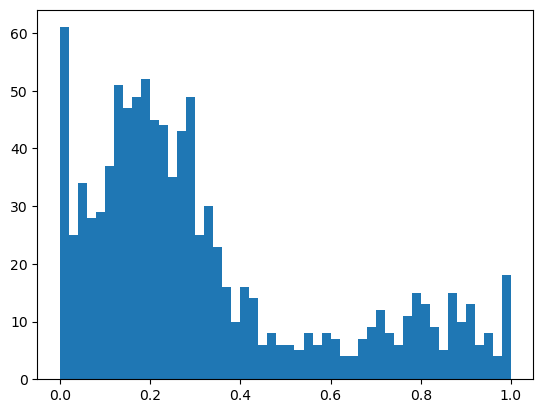

In [21]:
N = 1000
ks_avg = [0,0,10]
H = stratified_er_hypergraph(N, ks_avg, p_type='degree')

means = [0.2,0.8]
std = 0.1
seeds = np.random.choice(H.nodes, 2, replace=False)
if seeds[0] in H.nodes.neighbors(seeds[1]):
    print('neighboring seeds!')
ops = {seeds[0]:means[0], seeds[1]:means[1]}
new_seeds = []

while len(ops)<N:
    for s in seeds:
        for n in list(H.nodes.neighbors(s)):
            if n not in ops.keys():
                op_n = np.random.normal(ops[s], std)
                ops[n] = 0. if op_n<0 else 1. if op_n>1 else op_n
                new_seeds.append(n)
    seeds = new_seeds

plt.hist(ops.values(), bins=50)
plt.show()

### Second trial:
Select a fraction $f$ of nodes and assign them opinions according to the bimodal. Then the other 1-f nodes choose one of their neighbors and copy their opinion with some noise (gaussian centered in the neighbor’s opinion).

In [6]:
# draw initial opinions from bimodal distribution
def bimodal_distribution(N, means, std):
    n_samp = N*2
    samp1 = np.random.normal(means[0], std, n_samp)
    samp2 = np.random.normal(means[1], std, n_samp)
    samp = [i for i in np.hstack((samp1,samp2)) if i>0. and i<1.]
    shuffle(samp)
    return samp[:N]

In [7]:
N = 2000
ks_avg = [0,0,10]
H = stratified_er_hypergraph(N, ks_avg, p_type='degree')
H.cleanup()

means = [0.3,0.7]
std = 0.08

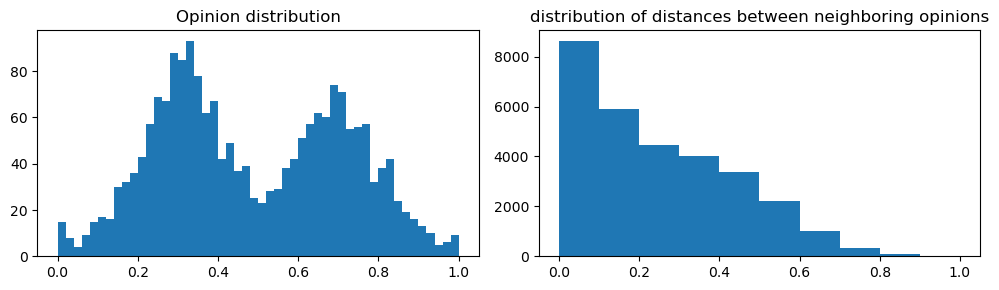

Average of second histogram:  0.2500574517989704


In [8]:
f_seeds = 0.3
n_seeds = int(N*f_seeds)
seeds = np.random.choice(H.nodes, n_seeds, replace=False)
op_seeds = bimodal_distribution(n_seeds, means, std)
ops = {s:o for s,o in zip(seeds,op_seeds)}

while len(ops)<N:
    for n in H.nodes:
        if n not in ops.keys():
            # nieghbors of n that already have an opinion
            neig_with_op = list( set(ops.keys()).intersection(H.nodes.neighbors(n)) )
            if len(neig_with_op):
                op_n = np.random.normal(ops[neig_with_op[0]], std)
                ops[n] = 0. if op_n<0 else 1. if op_n>1 else op_n

fig, ax = plt.subplots(1,2, figsize=(10,3))
ax[0].hist(ops.values(), bins=50)
ax[0].set_title('Opinion distribution')

# distance between opinions of two neighboring nodes
G = xgi.to_graph(H)
distances = [abs(ops[e[0]] - ops[e[1]]) for e in G.edges]
ax[1].hist(distances)
ax[1].set_title('distribution of distances between neighboring opinions')

plt.tight_layout()
plt.show()

print('Average of second histogram: ', np.mean(distances))

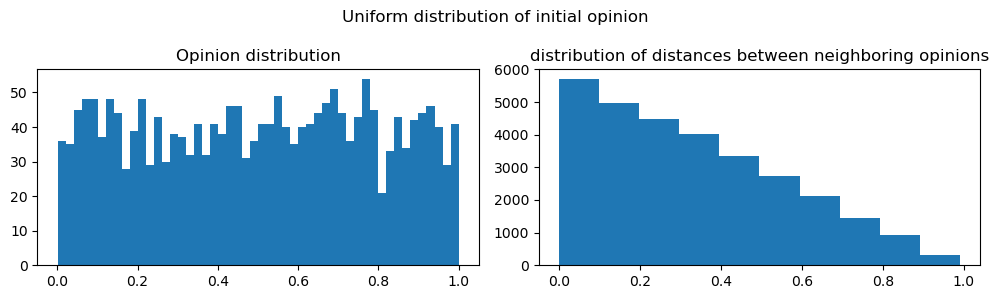

Average of second histogram:  0.3314521918623281


In [11]:
# COMPARISON WITH UNIFORM DISTRIBUTION
ops = np.random.random(len(H.nodes))
ops_dict = {n:o for n,o in zip(H.nodes,ops)}

fig, ax = plt.subplots(1,2, figsize=(10,3))
ax[0].hist(ops, bins=50)
ax[0].set_title('Opinion distribution')

# distance between opinions of two neighboring nodes
G = xgi.to_graph(H)
distances = [abs(ops_dict[e[0]] - ops_dict[e[1]]) for e in G.edges]
ax[1].hist(distances)
ax[1].set_title('distribution of distances between neighboring opinions')

plt.suptitle('Uniform distribution of initial opinion')

plt.tight_layout()
plt.show()

print('Average of second histogram: ', np.mean(distances))

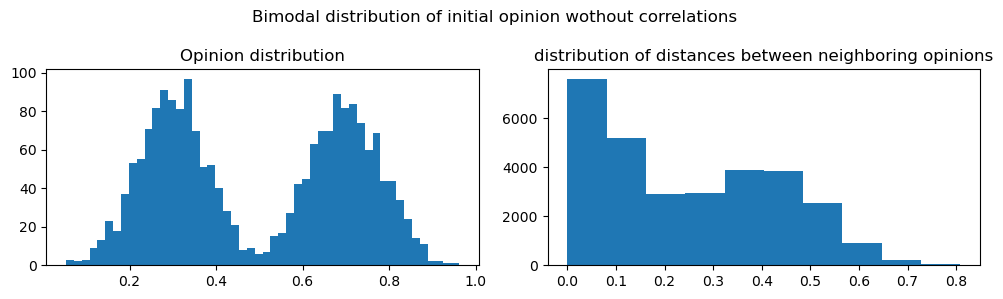

Average of second histogram:  0.24870501219717317


In [12]:
# COMPARISON WITH BIMODAL DISTRIBUTION WITHOUT CORRELATION
ops = bimodal_distribution(N, means, std)
ops_dict = {n:o for n,o in zip(H.nodes, ops)}

fig, ax = plt.subplots(1,2, figsize=(10,3))
ax[0].hist(ops, bins=50)
ax[0].set_title('Opinion distribution')

# distance between opinions of two neighboring nodes
G = xgi.to_graph(H)
distances = [abs(ops_dict[e[0]] - ops_dict[e[1]]) for e in G.edges]
ax[1].hist(distances)
ax[1].set_title('distribution of distances between neighboring opinions')

plt.suptitle('Bimodal distribution of initial opinion wothout correlations')

plt.tight_layout()
plt.show()

print('Average of second histogram: ', np.mean(distances))

In [19]:
import networkx as nx

G = xgi.to_graph(H)
nx.diameter(G)

4

## To try:
To implement bimodal distributions of initial opinions correlated with strucutre,
Try ER hypergraph with higher diameter (lower hyperdegree) and/or empirical hypergraphs (SocioPatterns)

In [10]:
N = 2000
ks_avg = [0,0,10]
H = stratified_er_hypergraph(N, ks_avg, p_type='degree')
# hyperdegrees
hds = H.nodes.degree.aslist()
counts_hd = dict()
for deg in sorted(hds):
    if deg in counts_hd.keys():
        counts_hd[deg]+=1
    else:
        counts_hd[deg]=1

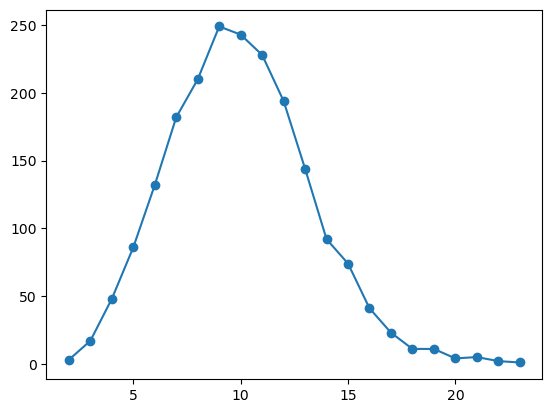

In [16]:
x = sorted(counts_hd.keys())
y = [counts_hd[i] for i in x]

plt.plot(x,y, marker='o')
#plt.yscale('log')

plt.show()